# Homework 4

## Polynomial kernel SVM

In [209]:
seed = 67

In [210]:
import pandas as pd
from sklearn.model_selection import train_test_split

data = pd.read_csv(filepath_or_buffer="svm_data_3.csv", header=None, names=["feature1", "feature2", "label"])

X = data.iloc[:, :-1]
y = data.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=seed, stratify=y)

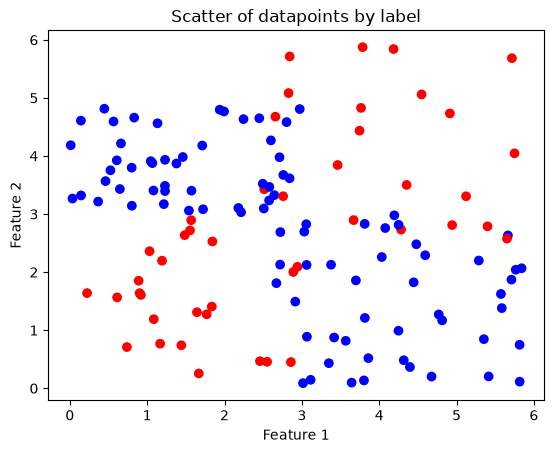

In [211]:
import matplotlib.pyplot as plt

plt.scatter(X_train["feature1"], X_train["feature2"], c=y_train, cmap="bwr")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Scatter of datapoints by label")
plt.show()

I can not learn anything reasonable with a linear SVM model.

In [212]:
import numpy as np

values, counts = np.unique(y_train, return_counts=True)
print(f"{values[0]}: {counts[0]}\n{values[1]}: {counts[1]}")

0.0: 90
1.0: 45


In [213]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold

model = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="poly", max_iter=100_000))
])

param_grid={
    "svc__C": [1, 10, 100],
    "svc__degree": [1, 2, 3],
    "svc__gamma": [0.1, 1, 10],
    "svc__coef0": [0, 1, 2, 3]
}

stratified_5_fold = StratifiedKFold(5)

grid_search=GridSearchCV(estimator=model, param_grid=param_grid, scoring="f1", cv=stratified_5_fold, n_jobs=-1, refit=True)

grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...ter=100000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'svc__C': [1, 10, ...], 'svc__coef0': [0, 1, ...], 'svc__degree': [1, 2, ...], 'svc__gamma': [0.1, 1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo...shuffle=False)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added."

In [214]:
C, degree, gamma, coef0 = grid_search.best_params_.values()
best_score = grid_search.best_score_
print(f"C: {C}")
print(f"degree: {degree}")
print(f"gamma: {gamma}")
print(f"coef0: {coef0}")

print(f"\nF1-score: {best_score}")

C: 10
degree: 2
gamma: 2
coef0: 10

F1-score: 0.8555555555555555


In [215]:
from sklearn.metrics import f1_score

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
test_score = f1_score(y_test, y_pred)
print(f"F1-score: {test_score}")


F1-score: 0.7272727272727273


Time to draw a grid of points

In [216]:
xs = np.linspace(X_train["feature1"].min(), X_train["feature1"].max(), 100)
ys = np.linspace(X_train["feature2"].min(), X_train["feature2"].max(), 100)

xx, yy = np.meshgrid(xs, ys)

grid = np.column_stack([xx.flatten(), yy.flatten()])

print(grid)

[[0.01150284 0.08801496]
 [0.07039109 0.08801496]
 [0.12927935 0.08801496]
 ...
 [5.72366331 5.87396876]
 [5.78255156 5.87396876]
 [5.84143981 5.87396876]]


Run all points in grid through decision function

In [ ]:
Z = best_model.decision_function(grid).reshape(xx.shape)


c:\Users\Magnus\Desktop\inf264\homework4\.venv\Lib\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


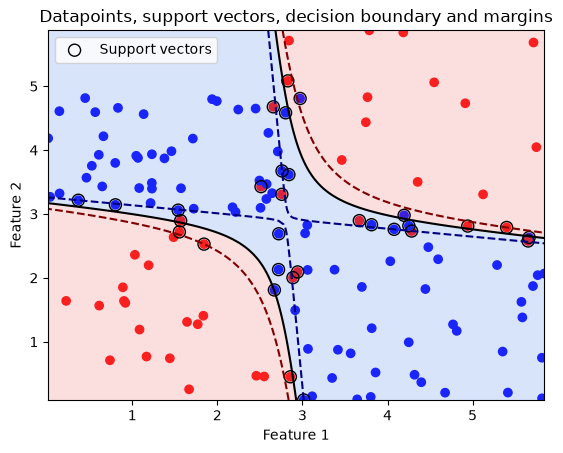

In [218]:
plt.scatter(X_train["feature1"], X_train["feature2"], c=y_train, cmap="bwr")
plt.contour(xx, yy, Z, levels=[-1, 0, 1], colors=["navy", "black", "maroon"], linestyles=["dashed", "solid", "dashed"])
plt.contourf(xx, yy, Z, levels=[Z.min(), 0, Z.max()], colors=["cornflowerblue", "lightcoral"], alpha=0.25)

support_vectors = best_model["scaler"].inverse_transform(best_model["svc"].support_vectors_)
plt.scatter(support_vectors[:, 0], support_vectors[:, 1], label="Support vectors", facecolors="none", edgecolors="black", s=75)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Datapoints, support vectors, decision boundary and margins")
plt.legend()
plt.show()

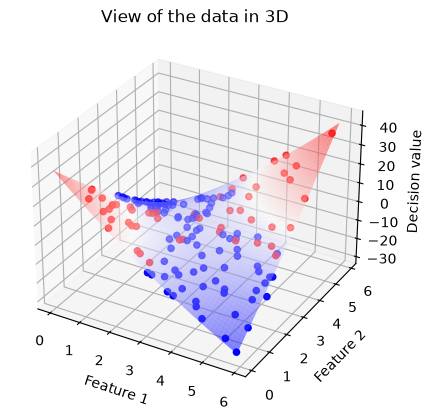

In [229]:
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
ax.plot_surface(xx, yy, Z, cmap="bwr", alpha=0.5)
ax.scatter3D(X["feature1"], X["feature2"], best_model.decision_function(X), c=y, cmap="bwr", marker="o")

ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.set_zlabel("Decision value")
ax.set_title("View of the data in 3D")

plt.show()